<a href="https://colab.research.google.com/github/carolcalandrine/Analise-churn/blob/main/Airbnb_Rio_de_Janeiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---


# Análise de dados do Airbnb - Rio de Janeiro

---



O **Airbnb** é uma plataforma global de aluguel de hospedagens por temporada
que conecta anfitriões e viajantes em mais de 190 países. Seu grande
diferencial está em oferecer alternativas às hospedagens tradicionais,
com opções que vão desde quartos compartilhados até casas e apartamentos
inteiros. Além da variedade, o custo costuma ser mais acessível que o de
hotéis convencionais, variando conforme a cidade, o período e o tipo de
acomodação escolhida.

No contexto brasileiro, o **Rio de Janeiro** se destaca como um dos destinos
mais procurados da plataforma. Com atrações como o Cristo Redentor, as
praias de Copacabana e Ipanema e o famoso Carnaval, a cidade atrai
milhões de turistas nacionais e internacionais por ano, gerando uma alta
demanda por hospedagens alternativas e acessíveis.

<center><img alt="Rio de Janeiro" width="70%" src="https://images.unsplash.com/photo-1483729558449-99ef09a8c325?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"></center>

## **Objetivo**
**Este projeto tem como objetivo analisar os dados do Airbnb no Rio de
Janeiro, buscando entender o comportamento do mercado de hospedagens
na cidade. Por meio de uma análise exploratória, foram investigados
aspectos como distribuição de preços, tipos de acomodação, bairros
com maior oferta e perfil dos anfitriões**




## **Obtenção dos Dados e Importação de Bibliotecas**
Os dados utilizados neste projeto foram obtidos através do Inside Airbnb,
uma plataforma que disponibiliza dados públicos sobre listagens do Airbnb
em diversas cidades do mundo. O dataset utilizado contém informações sobre
os imóveis anunciados no Rio de Janeiro no período de setembro de 2025,
incluindo localização, preços, tipos de acomodação e avaliações dos hóspedes.

Para a análise, foram utilizadas as seguintes bibliotecas:
- Pandas: manipulação e análise dos dados
- NumPy: operações numéricas
- Matplotlib: criação de visualizações
- Seaborn: visualizações estatísticas

In [25]:
#importação de bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [77]:
# Importação do arquivo .xlx
df = pd.read_csv('/content/listings.csv')


## **Dicionário das Variáveis**
Abaixo tem-se as variáveis utilizadas no dataset:

* `id` - número de id gerado para identificar o imóvel
* `name` - nome da propriedade anunciada
* `host_id` - número de id do anfitrião da propriedade
* `host_name` - nome do anfitrião responsável pelo imóvel
* `calculated_host_listings_count` - quantidade de imóveis do mesmo anfitrião
* `neighbourhood_group` - agrupamento geográfico mais amplo dentro da cidade
* `neighbourhood` - bairro onde o imóvel está localizado dentro do Rio de Janeiro
* `latitude` - coordenada geográfica de latitude do imóvel.
* `longitude` - coordenada geográfica de longitude do imóvel.
* `room_type` - tipo de acomodação oferecida, podendo ser:
* `price` - preço da hospedagem do imóvel
* `minimum_nights` - número mínimo de noites exigidas para reserva do imóvel.
* `number_of_reviews` - número de avaliações que a propriedade possui
* `last_review` - data da última avaliação recebida pelo imóvel
* `reviews_per_month` - quantidade de avaliações por mês
* `availability_365` - número de dias disponíveis para reserva ao longo de 365 dias
* `number_of_reviews_ltm` - número de avaliações nos últimos doze meses
* `license` - licença ou registro necessário para o imóvel

## **Análise Exploratória dos Dados**

### **1. Análise Inicial e Limpeza dos Dados**

#### **1.1 Visão Geral dos Dados**
A partir do dataset importado, é realizada uma visão geral da sua estrutura,
identificando os tipos de variáveis, valores ausentes e a diversidade de cada
coluna, sendo um passo essencial antes de qualquer análise.

In [72]:
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')

info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': round(df.isnull().mean() * 100, 2),
    'Valores únicos': df.nunique(),
    'Exemplo de valores': df.apply(lambda x: ', '.join(map(str, x.dropna().unique()[:3])))
  })
info

Linhas: 43068 | Colunas: 18


,Tipo,Nulos,% Nulos,Valores únicos,Exemplo de valores
id,int64,0,0.00,43068,"821198084644106078, 821198370698658112, 821200..."
name,object,0,0.00,40833,"Bright and Peaceful Leblon Loft, Copacabana 10..."
host_id,int64,0,0.00,24993,"84350716, 4347269, 499903412"
host_name,object,11,0.03,7725,"Katrina, Patrick, Vanessa"
neighbourhood_group,float64,43068,100.00,0,
neighbourhood,object,0,0.00,152,"Leblon, Copacabana, Pavuna"
latitude,float64,0,0.00,26137,"-22.98281778975964, -22.98409, -22.81491149710329"
longitude,float64,0,0.00,27483,"-43.222457084655744, -43.19177, -43.3790114389..."
room_type,object,0,0.00,4,"Entire home/apt, Private room, Shared room"
price,float64,4398,10.21,2600,"580.0, 1900.0, 700.0"


A partir dessa análise pode-se notar que algumas variáveis apresentam
valores ausentes no dataset:

- As colunas `reviews_per_month` e `last_review` apresentam 21,33% de valores faltantes;
- A coluna `price` possui aproximadamente 10% dos seus valores ausentes;
- As variáveis `neighbourhood_group` e `license` possuem somente valores ausentes, sendo necessária a remoção das colunas do dataset.

#### **1.2 Análise Estatística dos Dados**
Foi realizada a análise estatística das variáveis numéricas do dataset
para verificar o comportamento dos dados, identificando possíveis
inconsistências e padrões antes da limpeza.

In [28]:
df[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,38670.000000,43068.000000,43068.000000,33882.000000,43068.000000,43068.000000,43068.000000
mean,717.535325,3.652155,26.184545,1.202350,9.971441,191.438678,8.985024
std,4388.082802,15.394401,48.648266,1.306897,26.119941,126.139517,13.351561
min,30.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,202.000000,1.000000,1.000000,0.240000,1.000000,85.000000,0.000000
50%,317.000000,2.000000,7.000000,0.740000,2.000000,177.000000,3.000000
75%,565.000000,3.000000,30.000000,1.780000,6.000000,327.000000,13.000000
max,500000.000000,1000.000000,760.000000,15.000000,232.000000,365.000000,163.000000


A partir da análise estatística, pode-se observar que:

- A variável `price` apresenta média de R\$ 717,53, porém com desvio padrão
elevado e valor máximo de R\$ 500.000, indicando a presença de outliers;
- A variável `minimum_nights` possui mediana de 2 noites, mas valor máximo
de 1.000 noites, o que indica registros inconsistentes da variável;
- A variável `availability_365` apresenta média de 191 dias, indicando que
os imóveis ficam disponíveis em média pouco mais da metade do ano.

#### **1.3 Análise de Outliers**
Outliers são valores extremos que se distanciam significativamente dos demais
dados do dataset, podendo distorcer os resultados da análise e levar a
conclusões equivocadas.

Para identificá-los, primeiramente foi realizado um
histograma para visualizar a distribuição geral das variáveis numéricas e,
em seguida, foram gerados boxplots para as variáveis `price` e `minimum_nights`, permitindo uma visualização mais clara dos valores presentes nos dados.

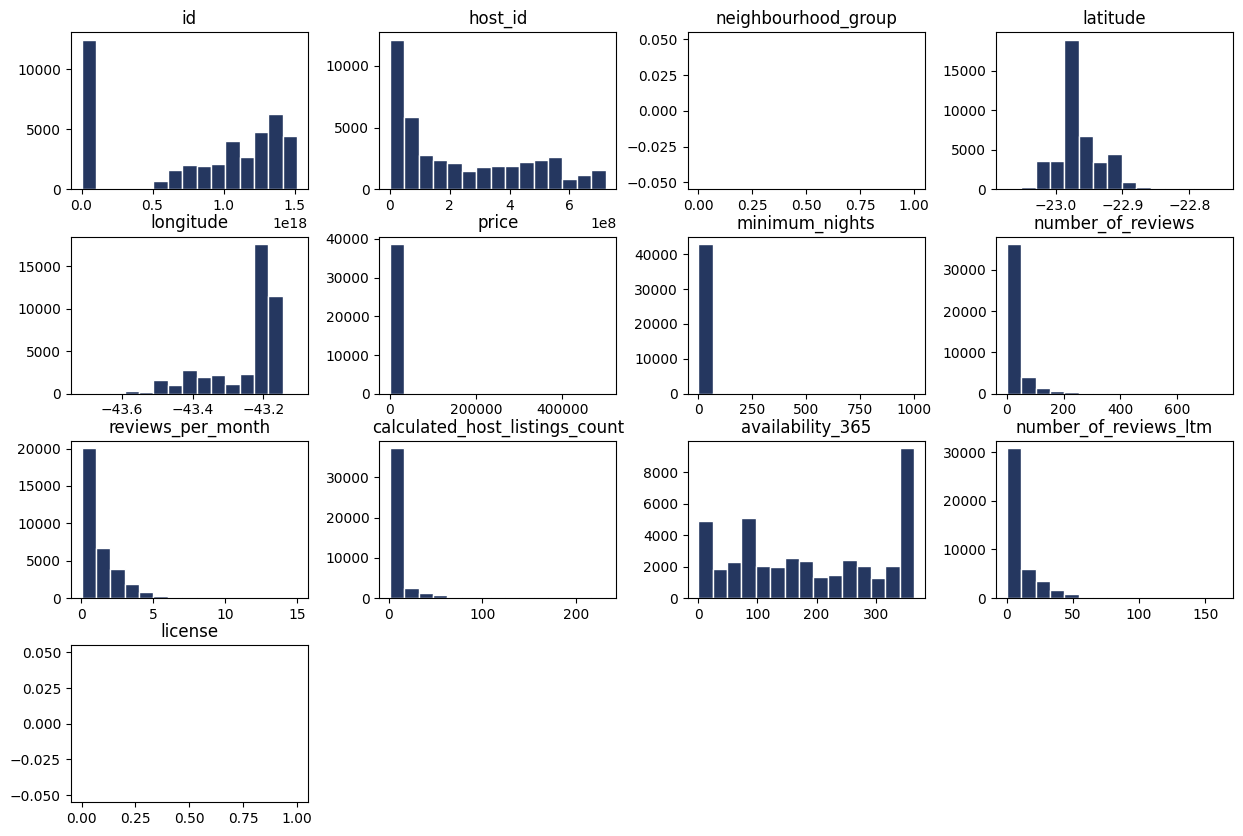

In [29]:
# Histograma das variáveis numéricas
df.hist(bins=15, figsize=(15, 10), color="#253760",  edgecolor='white', grid=False)
plt.show()

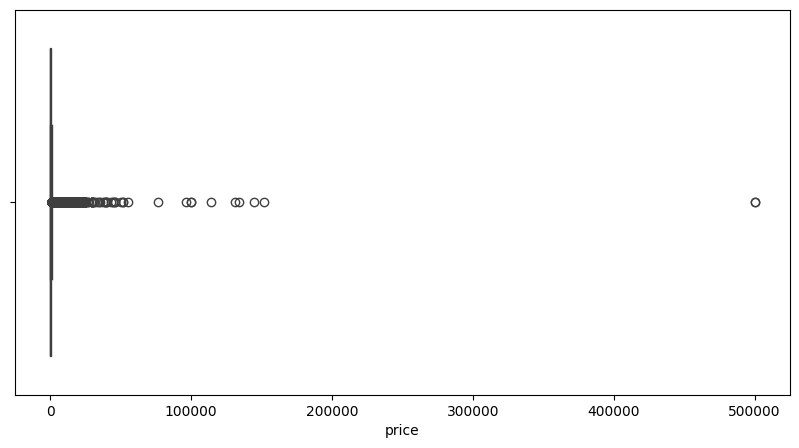

In [30]:
# Boxplot da variável 'price'
plt.figure(figsize=(10,5))
sns.boxplot(x=df['price']);

O boxplot confirma a presença de valores extremos na variável `price`,
com imóveis chegando a R$ 500.000, muito acima do comportamento esperado.

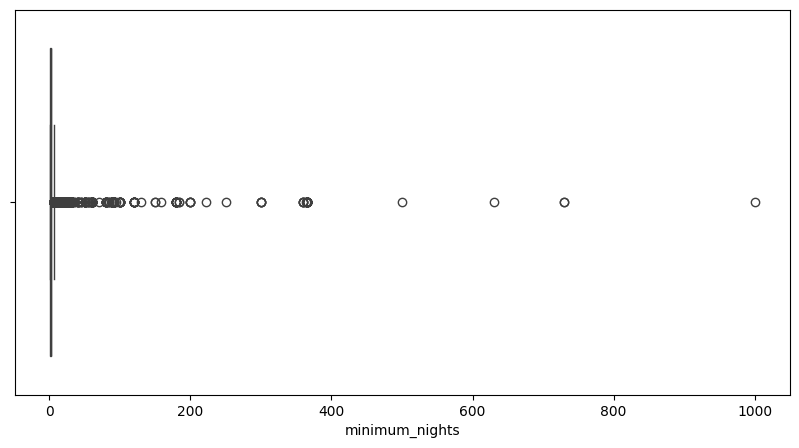

In [31]:
# Boxplot da variável 'minimum_nights'
plt.figure(figsize=(10,5))
sns.boxplot(x=df['minimum_nights']);

O boxplot evidencia outliers na variável `minimum_nights`, com registros
chegando a 1.000 noites, o que representa valores inconsistentes para o contexto de hospedagem.

#### **1.4 Limpeza dos Dados**
Após a identificação dos outliers, foi realizada a limpeza dos dados com
o objetivo de remover inconsistências e garantir a qualidade das análises posteriores.

In [32]:
# Remoção das colunas neighbourhood_group e license
df.drop(['neighbourhood_group', 'license'], axis=1, inplace=True)


Para a remoção dos outliers, foi calculado o Intervalo Interquartil de cada variável a partir da diferença entre o 3º e o 1º quartil. Com base nisso, foi definido o limite superior para `price` e para `minimum_nights`, sendo removidos todos os registros que ultrapassaram esses limites.

In [45]:
# Cálculo IQR para variável 'price'
q1_price = df.price.quantile(.25)
q3_price = df.price.quantile(.75)
IQR_price = q3_price - q1_price
print(f'1º Quartil: {q1_price:.2f}')
print(f'3º Quartil: {q3_price:.2f}')
print(f'Valor do IQR: {IQR_price:.2f}')

# Limite para considerar outlier
sup_price = q3_price + (1.5 * IQR_price)
print(f'Valor Limite Superior: {sup_price:.2f}')

1º Quartil: 202.00
3º Quartil: 565.00
Valor do IQR: 363.00
Valor Limite Superior: 1109.50


In [47]:
# Cálculo IQR para variável 'minimum_nights'
q1_minimum_nights = df.minimum_nights.quantile(.25)
q3_minimum_nights = df.minimum_nights.quantile(.75)
IQR_minimum_nights = q3_minimum_nights - q1_minimum_nights
print(f'1º Quartil: {q1_minimum_nights:.0f}')
print(f'3º Quartil: {q3_minimum_nights:.0f}')
print(f'Valor do IQR: {IQR_minimum_nights:.0f}')

# Limite para considerar outlier
sup_minimum_nights = q3_minimum_nights + (1.5 * IQR_minimum_nights)
print(f'Valor do Limite Superior: {sup_minimum_nights:.0f}')

1º Quartil: 1
3º Quartil: 3
Valor do IQR: 2
Valor do Limite Superior: 6


 - Para a variável `price`, o limite superior encontrado foi de R\$ 1109,50.
 - Para a variável `minimum_nights`, o limite superior encontrado foi de 6 noites.

In [35]:
# Quantidade de valores acima de 1109,50 para price
print('price - valores acima de 1109,50:')
print(f'{len(df[df.price > 1109.50])} entradas')
print(f'{(len(df[df.price > 1109.50]) / df.shape[0])*100:.2f} %')

price - valores acima de 1109,50:
3792 entradas
8.80 %


In [36]:
# Quantidade de valores acima de 6 para minimum_nights
print('minimum_nights - valores acima de 6:')
print(f'{len(df[df.minimum_nights > 11])} entradas')
print(f'{(len(df[df.minimum_nights > 11]) / df.shape[0])*100:.2f} %')

minimum_nights -> valores acima de 6:
1155 entradas
2.68 %


In [37]:
# Cópia do antigo DataFrame para a remoção dos outliers
df_clean = df.copy()

# Remoção dos outliers da variável 'price'
df_clean.drop(df_clean[df_clean.price > 1109.50].index, axis=0, inplace=True)

# Remoção dos outliers da variável 'minimum_nights'
df_clean.drop(df_clean[df_clean.minimum_nights > 6].index, axis=0, inplace=True)

Foi criada uma cópia do dataset original chamada `df_clean`, preservando o
dataframe inicial. Em seguida, os outliers identificados foram removidos.

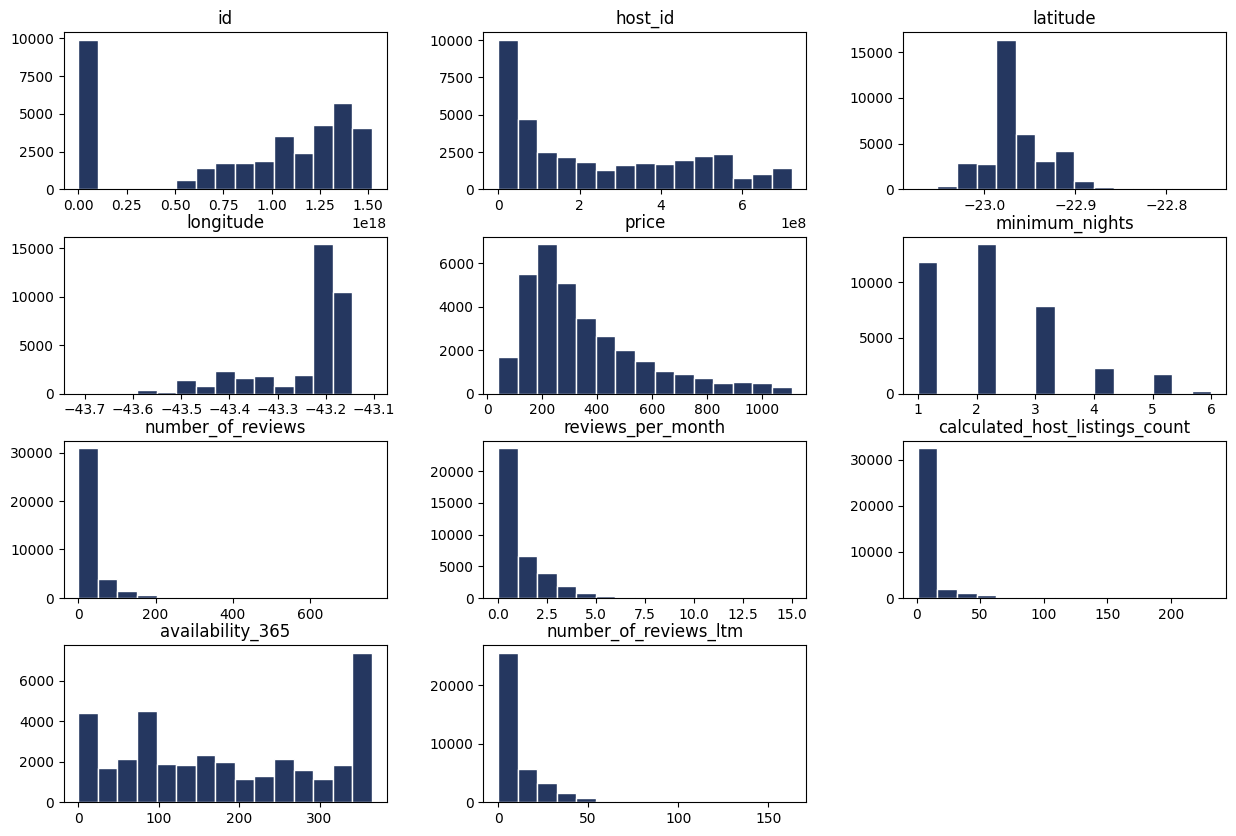

In [38]:
# Histograma das variáveis numéricas após a limpeza do outliers
df_clean.hist(bins=15, figsize=(15, 10), color="#253760", edgecolor='white',grid=False)
plt.show()

Após a remoção dos outliers, os histogramas mostram uma distribuição mais
uniforme das variáveis `price` e `minimum_nights`.

In [78]:
# Análise Estatística após a limpeza dos outliers
round(df_clean[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'number_of_reviews_ltm']].describe(),2)

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,number_of_reviews_ltm
count,33372.00,37400.00,37400.00,37400.00,37400.00,37400.00
mean,355.39,2.19,28.58,1.05,10.04,9.93
std,223.18,1.13,50.77,1.30,26.70,13.84
min,40.00,1.00,0.00,0.00,1.00,0.00
25%,195.00,1.00,1.00,0.11,1.00,0.00
50%,287.00,2.00,9.00,0.54,2.00,4.00
75%,458.00,3.00,33.00,1.59,6.00,15.00
max,1109.00,6.00,760.00,15.00,232.00,163.00


### **2. Análise dos Dados**


A partir das limpezas dos dados será necessário responder algumas perguntas que

#### **2.1 Quais bairros possuem a maior quantidade de imóveis anunciados no Airbnb no Rio de Janeiro?**

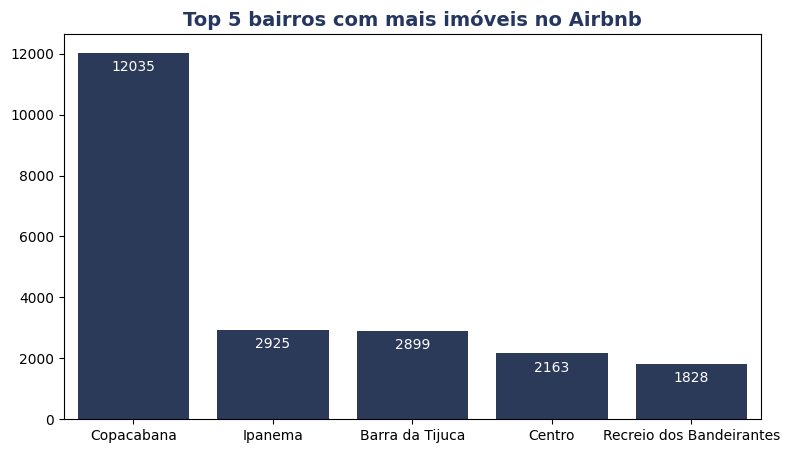

In [79]:
# @title
# Top 5 bairros com mais imóveis
top_imoveis = df_clean.neighbourhood.value_counts().head(5)

# Tamanho da figura
plt.figure(figsize=(9,5))

# Gráfico
sns.barplot(
    x=top_imoveis.index,
    y=top_imoveis.values,
    color="#253760"
)

# Título
plt.title(
    "Top 5 bairros com mais imóveis no Airbnb",
    color="#253760",
    fontweight='bold',
    fontsize=14
)

#
for i, valor in enumerate(top_imoveis.values):
    plt.text(
        i,
        valor - 600,
        f'{valor:.0f}',
        ha='center',
        color='white'
    )

# Nome dos eixos
plt.xlabel('')
plt.ylabel('')

# Remover grade
plt.grid(False)

# Mostrar gráfico
plt.show()

A análise dos bairros com maior oferta de imóveis no Airbnb revela uma
concentração expressiva em Copacabana, com 12.035. Esse resultado
era esperado, dado que o bairro é um dos mais turísticos do Rio de Janeiro.
Abaixo, nota-se que:

* Copacabana lidera com folga, reflexo da alta demanda turística da região;
* Ipanema e Barra da Tijuca aparecem empatadas, mostrando potencial de
mercado semelhante entre as duas regiões;
* A presença de Centro e Recreio no top 5 indica que a oferta se expande
além da zona sul.

#### **2.2 Qual tipo de acomodação possui maior preço médio?**

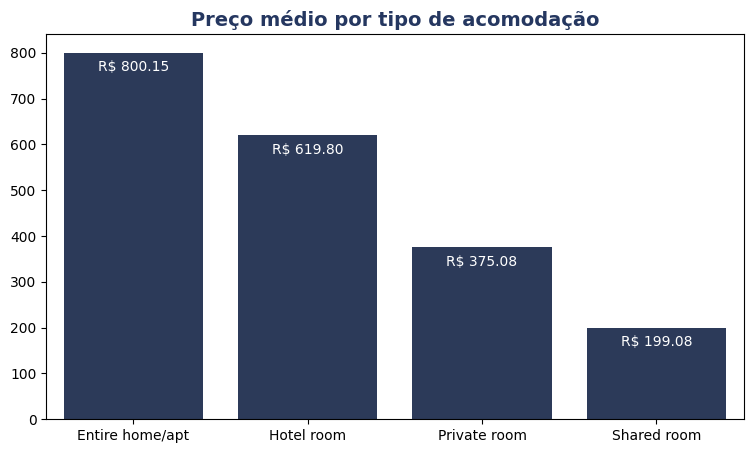

In [80]:
# @title
preco_acomodacao = df.groupby('room_type')['price'].mean().sort_values(ascending=False)

# Tamanho da figura
plt.figure(figsize=(9,5))

# Gráfico
sns.barplot(
    x=preco_acomodacao.index,
    y=preco_acomodacao.values,
    color="#253760"
)

# Título
plt.title(
    "Preço médio por tipo de acomodação",
    color="#253760",
    fontweight='bold',
    fontsize=14
)

for i, valor in enumerate(preco_acomodacao.values):
    plt.text(
        i,
        valor - 40,
        f'R$ {valor:.2f}',
        ha='center',
        color='white'
    )

# Nome dos eixos
plt.xlabel('')
plt.ylabel('')

# Remover grade
plt.grid(False)

# Mostrar gráfico
plt.show()


A análise do preço médio por tipo de acomodação mostra uma clara hierarquia
entre as opções disponíveis na plataforma:

* Apartamentos e casas lideram com R\$ 800,15, dado que oferecem mais espaço e privacidade;
* Hotel room (R\$ 619,80) aparece mais barato que apartamentos e casas, mostrando que o Airbnb compete diretamente com a hotelaria tradicional;
* Quartos privativos (R\$ 375,08) e compartilhados (R\$ 199,08) atendem um
público mais sensível ao preço, ampliando o alcance da plataforma.

#### **2.3 Como se distribui o preço dos imóveis e qual o valor médio?**

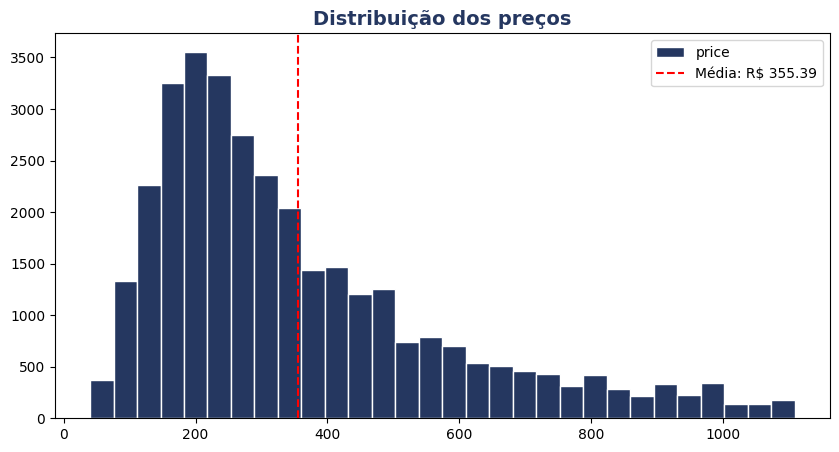

In [81]:
fig, ax = plt.subplots(figsize=(10, 5))
df_clean['price'].plot(kind='hist', bins=30, color='#253760', edgecolor='white', grid=False)
ax.axvline(df_clean['price'].mean(), color='red', linestyle='--', label=f'Média: R$ {df_clean["price"].mean():.2f}')
plt.title("Distribuição dos preços",color="#253760", fontweight='bold', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('')
ax.legend()
plt.show()

A distribuição dos preços revela o comportamento do mercado carioca de
hospedagens. Abaixo, nota-se que:

* A maioria dos imóveis está concentrada entre R\$ 100 e R\$ 400, indicando
um mercado predominantemente voltado para o público de médio padrão;
* A média de R\$ 355,39 é influenciada pelos imóveis de alto padrão,
puxando o valor acima do pico da distribuição.

#### **2.4 Qual a correlação entre as variáveis?**

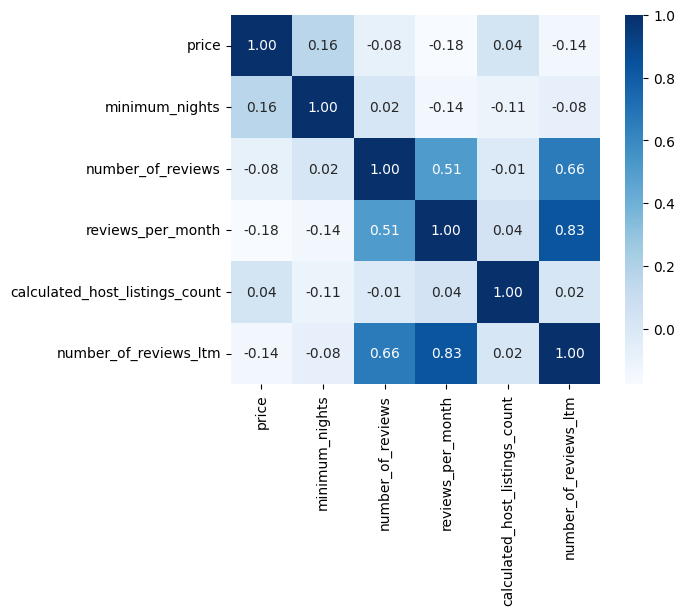

In [82]:
# Criação de uma matriz de correlação
corr = df_clean[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'number_of_reviews_ltm']].corr()

# Plotagem do
sns.heatmap(corr, cmap='Blues', fmt='.2f', square=True, annot=True)
plt.show()

A matriz de correlação revela que o `price` não apresenta correlação forte
com nenhuma das variáveis analisadas, indicando que o preço é influenciado
por fatores não capturados pelo dataset, como localização e qualidade do imóvel.

#### **2.5 Mapa de calor dos preços dos imóveis do Rio de Janeiro**

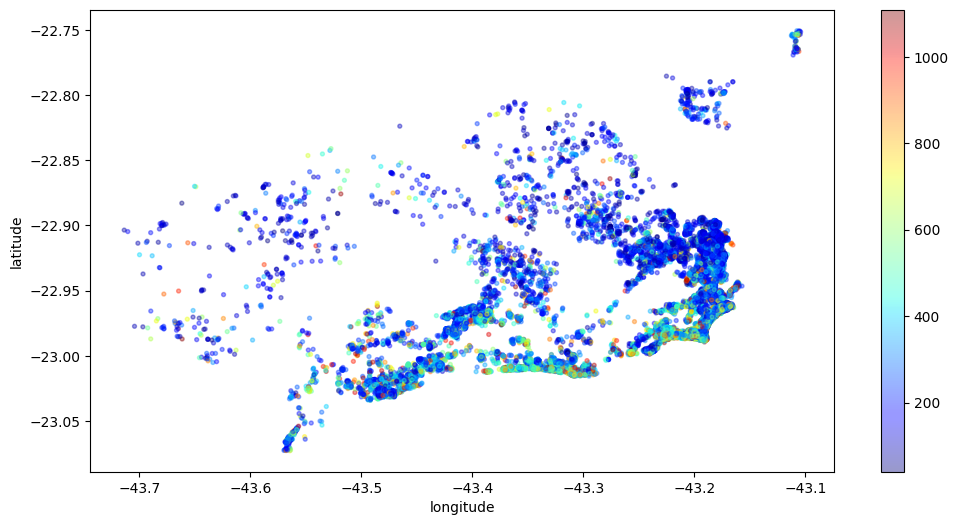

In [83]:
# Quantidade de imóveis pela latitude-longitude
df_clean.plot(kind="scatter",
              x='longitude',
              y='latitude',
              alpha=0.4,
              c=df_clean['price'],
              s=8,
              cmap=plt.get_cmap('jet'),
              figsize=(12,6));

## **Conclusão**
A análise dos dados do Airbnb no Rio de Janeiro permitiu identificar
importantes características do mercado de hospedagens na cidade.

Entre os principais achados, destacam-se:

* Copacabana concentra a maior oferta de imóveis, porém a alta competição
pressiona os preços para baixo na região;
* Apartamentos e casas são o tipo de acomodação mais caro, custando em
média 4x mais que quartos compartilhados;
* O mercado carioca é predominantemente voltado para o público de médio
padrão, com a maioria dos imóveis concentrada entre R\$ 100 e R\$ 400;
* Os preços mais elevados estão concentrados na zona sul, especialmente
em Ipanema e Leblon

Em relação à qualidade dos dados, a variável `price` apresentou 10% de
valores ausentes que foram mantidos no dataset para evitar distorções
na análise.

Por fim, o preço não apresenta correlação forte com nenhuma das variáveis
analisadas, indicando que outros fatores podem ser determinantes no valor cobrado.